In [3]:
import numpy as np
import matplotlib.pyplot as plt

Step size: 0.01
Solution may not be Entirely Stable ;)
Magnitude: 1.0000

Step size: 0.05
Solution may not be Entirely Stable ;)
Magnitude: 1.0012

Step size: 0.1
Solution may not be Entirely Stable ;)
Magnitude: 1.0050

Step size: 0.2
Solution may not be Entirely Stable ;)
Magnitude: 1.0198

Step size: 0.5
Solution may not be Entirely Stable ;)
Magnitude: 1.1180



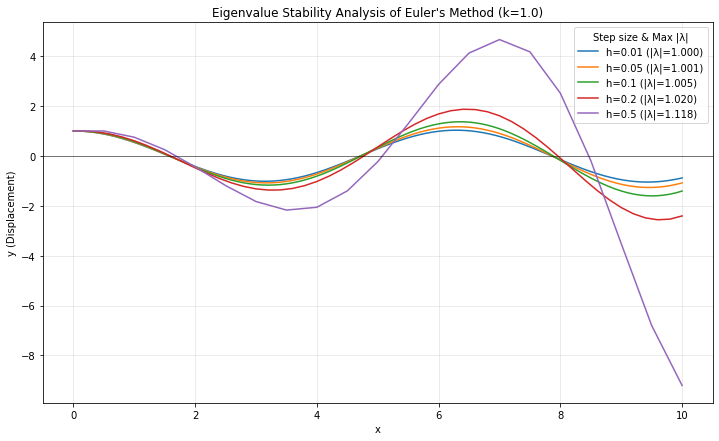

In [4]:
k = 1.0
x_start = 0    
x_end = 10     
y_0 = 1.0
v_0 = 0.0
h_values = [0.01, 0.05, 0.1, 0.2, 0.5] 

A_cont = np.array([[0, 1], 
                   [-k, 0]])

plt.figure(figsize=(12, 7))

for h in h_values:
    G = np.eye(2) + h * A_cont
    
    eigenvalues = np.linalg.eigvals(G)
    max_eigen_mag = np.max(np.abs(eigenvalues))
    
    print(f"Step size: {h}")
    if max_eigen_mag < 1.0:
        
        print("Solution is Stable")
        
    else:
        
        print("Solution may not be Entirely Stable ;)")
    print(f"Magnitude: {max_eigen_mag:.4f}\n")
    
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))
    y_values[0], v_values[0] = y_0, v_0
    
    for i in range(1, len(x_values)):
        
        curr_state = np.array([y_values[i-1], v_values[i-1]])
        next_state = G @ curr_state
        y_values[i], v_values[i] = next_state
        
        
    plt.plot(x_values, y_values, label=f'h={h} (|λ|={max_eigen_mag:.3f})')

    
plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.title(f"Eigenvalue Stability Analysis of Euler's Method (k={k})")
plt.xlabel("x")
plt.ylabel("y (Displacement)")
plt.legend(title="Step size & Max |λ|")
plt.grid(True, alpha=0.3)
plt.show()